# Hyperparameter Tuning - XGBoost & Random Forest

This notebook fine-tunes the two best-performing models from baseline comparison:
- XGBoost
- Random Forest

We use RandomizedSearchCV for efficient hyperparameter search and track all experiments with MLflow.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from src.feature_engineering import feature_engineering

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Preparation

Load the engineered features and apply the same feature selection as in baseline training.

In [2]:
# Load preprocessed data from feature engineering pipeline
X_train, X_val, X_test, y_train, y_val, y_test, scaler = feature_engineering()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set: 81393 samples, 212 features
Validation set: 10174 samples
Test set: 10175 samples

Class distribution in training set:
readmitted
0    0.5391
1    0.4609
Name: proportion, dtype: float64


In [3]:
# Feature selection using Random Forest importance (same as baseline)
# This ensures consistency with baseline experiments

# Group one-hot encoded columns by their base category
groups = {}
for col in X_train.columns:
    base = re.sub(r'_[^_]+$', '', col)
    groups.setdefault(base, []).append(col)

# Train a quick RF to get feature importances
selector_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
selector_model.fit(X_train, y_train)

# Select top 25 features, but include all columns from same categorical group
importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(25).index

final_features = set()
for g, cols in groups.items():
    if any(c in top_features for c in cols):
        final_features.update(cols)

# Apply feature selection to all sets
X_train = X_train[list(final_features)]
X_val = X_val[list(final_features)]
X_test = X_test[list(final_features)]

print(f"Selected {len(final_features)} features after grouping")

Selected 180 features after grouping


In [4]:
# Clean column names for XGBoost compatibility
for df in [X_train, X_val, X_test]:
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]

print("Column names cleaned for XGBoost compatibility")

Column names cleaned for XGBoost compatibility


## 2. MLflow Setup

In [5]:
# Configure MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("hyperparameter-tuning")

print("MLflow configured. Tracking URI: http://localhost:5000")
print("Experiment: hyperparameter-tuning")

MLflow configured. Tracking URI: http://localhost:5000
Experiment: hyperparameter-tuning


## 3. Define Hyperparameter Search Spaces

We define reasonable ranges for each hyperparameter based on common best practices.

In [6]:
# XGBoost hyperparameter search space
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1, 2, 3]  # helps with class imbalance
}

# Random Forest hyperparameter search space
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# Number of random combinations to try
N_ITER = 15
CV_FOLDS = 2

print(f"Search configuration:")
print(f"  - Random iterations: {N_ITER}")
print(f"  - CV folds: {CV_FOLDS}")

Search configuration:
  - Random iterations: 15
  - CV folds: 2


## 4. XGBoost Hyperparameter Tuning

In [7]:
print("Starting XGBoost hyperparameter tuning...")
print("="*50)

with mlflow.start_run(run_name="XGBoost_Tuning"):
    # Log search configuration
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("search_type", "RandomizedSearchCV")
    mlflow.log_param("n_iter", N_ITER)
    mlflow.log_param("cv_folds", CV_FOLDS)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "tuning")
    
    # Initialize base model
    xgb_base = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    # Randomized search with cross-validation
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_grid,
        n_iter=N_ITER,
        scoring='f1',  # optimize for F1 score
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=4,
        verbose=1
    )
    
    # Fit on training data
    xgb_search.fit(X_train, y_train)
    
    # Get best model and parameters
    best_xgb = xgb_search.best_estimator_
    best_xgb_params = xgb_search.best_params_
    
    # Log best hyperparameters
    for param, value in best_xgb_params.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    xgb_val_pred = best_xgb.predict(X_val)
    xgb_val_proba = best_xgb.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    xgb_metrics = {
        'accuracy': accuracy_score(y_val, xgb_val_pred),
        'f1': f1_score(y_val, xgb_val_pred),
        'precision': precision_score(y_val, xgb_val_pred),
        'recall': recall_score(y_val, xgb_val_pred),
        'roc_auc': roc_auc_score(y_val, xgb_val_proba),
        'cv_best_score': xgb_search.best_score_
    }
    
    # Log metrics
    for metric_name, metric_value in xgb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the tuned model
    mlflow.xgboost.log_model(best_xgb, "xgboost_tuned")
    
    print(f"\nBest XGBoost Parameters:")
    for param, value in best_xgb_params.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in xgb_metrics.items():
        print(f"  {metric}: {value:.4f}")

Starting XGBoost hyperparameter tuning...
Fitting 2 folds for each of 15 candidates, totalling 30 fits


2025/12/19 16:51:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:51:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best XGBoost Parameters:
  subsample: 0.7
  scale_pos_weight: 2
  n_estimators: 200
  min_child_weight: 3
  max_depth: 3
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 0.9

Validation Metrics:
  accuracy: 0.5638
  f1: 0.6538
  precision: 0.5154
  recall: 0.8938
  roc_auc: 0.6847
  cv_best_score: 0.6567
🏃 View run XGBoost_Tuning at: http://localhost:5000/#/experiments/668770909263748700/runs/0e1e7b6ae756431dbf3ae0b360d6f84a
🧪 View experiment at: http://localhost:5000/#/experiments/668770909263748700


## 5. Random Forest Hyperparameter Tuning

In [8]:
print("Starting Random Forest hyperparameter tuning...")
print("="*50)

with mlflow.start_run(run_name="RandomForest_Tuning"):
    # Log search configuration
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("search_type", "RandomizedSearchCV")
    mlflow.log_param("n_iter", N_ITER)
    mlflow.log_param("cv_folds", CV_FOLDS)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "tuning")
    
    # Initialize base model
    rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
    
    # Randomized search with cross-validation
    rf_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_param_grid,
        n_iter=N_ITER,
        scoring='f1',
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=4,
        verbose=1
    )
    
    # Fit on training data
    rf_search.fit(X_train, y_train)
    
    # Get best model and parameters
    best_rf = rf_search.best_estimator_
    best_rf_params = rf_search.best_params_
    
    # Log best hyperparameters
    for param, value in best_rf_params.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    rf_val_pred = best_rf.predict(X_val)
    rf_val_proba = best_rf.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    rf_metrics = {
        'accuracy': accuracy_score(y_val, rf_val_pred),
        'f1': f1_score(y_val, rf_val_pred),
        'precision': precision_score(y_val, rf_val_pred),
        'recall': recall_score(y_val, rf_val_pred),
        'roc_auc': roc_auc_score(y_val, rf_val_proba),
        'cv_best_score': rf_search.best_score_
    }
    
    # Log metrics
    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the tuned model
    mlflow.sklearn.log_model(best_rf, "random_forest_tuned")
    
    print(f"\nBest Random Forest Parameters:")
    for param, value in best_rf_params.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in rf_metrics.items():
        print(f"  {metric}: {value:.4f}")

Starting Random Forest hyperparameter tuning...
Fitting 2 folds for each of 15 candidates, totalling 30 fits


2025/12/19 16:55:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:55:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best Random Forest Parameters:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample

Validation Metrics:
  accuracy: 0.6351
  f1: 0.5924
  precision: 0.6106
  recall: 0.5752
  roc_auc: 0.6867
  cv_best_score: 0.5924
🏃 View run RandomForest_Tuning at: http://localhost:5000/#/experiments/668770909263748700/runs/96ebe1bf0bde4c14b45422fbb4c39567
🧪 View experiment at: http://localhost:5000/#/experiments/668770909263748700


## 6. Model Comparison & Final Evaluation on Test Set

In [9]:
# Compare tuned models
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC', 'CV Score'],
    'XGBoost': [xgb_metrics['accuracy'], xgb_metrics['f1'], xgb_metrics['precision'], 
               xgb_metrics['recall'], xgb_metrics['roc_auc'], xgb_metrics['cv_best_score']],
    'Random Forest': [rf_metrics['accuracy'], rf_metrics['f1'], rf_metrics['precision'],
                      rf_metrics['recall'], rf_metrics['roc_auc'], rf_metrics['cv_best_score']]
})

print("Validation Set Comparison (Tuned Models)")
print("="*50)
print(comparison_df.to_string(index=False))

# Determine best model based on F1 score
if xgb_metrics['f1'] >= rf_metrics['f1']:
    best_model = best_xgb
    best_model_name = "XGBoost"
    best_log_func = mlflow.xgboost.log_model
else:
    best_model = best_rf
    best_model_name = "RandomForest"
    best_log_func = mlflow.sklearn.log_model

print(f"\nBest model based on F1 score: {best_model_name}")

Validation Set Comparison (Tuned Models)
   Metric  XGBoost  Random Forest
 Accuracy 0.563790       0.635148
 F1 Score 0.653822       0.592357
Precision 0.515435       0.610595
   Recall 0.893794       0.575176
  ROC AUC 0.684719       0.686717
 CV Score 0.656725       0.592392

Best model based on F1 score: XGBoost


In [10]:
# Final evaluation on held-out test set
print("Final Evaluation on Test Set")
print("="*50)

with mlflow.start_run(run_name="Final_Test_Evaluation"):
    mlflow.log_param("model_type", best_model_name)
    mlflow.set_tag("stage", "final_evaluation")
    mlflow.set_tag("dataset", "test")
    
    # Predictions on test set
    test_pred = best_model.predict(X_test)
    test_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate final metrics
    final_metrics = {
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred),
        'test_precision': precision_score(y_test, test_pred),
        'test_recall': recall_score(y_test, test_pred),
        'test_roc_auc': roc_auc_score(y_test, test_proba)
    }
    
    # Log final metrics
    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the final model
    best_log_func(best_model, "final_model")
    
    print(f"\nTest Set Results ({best_model_name}):")
    for metric, value in final_metrics.items():
        print(f"  {metric.replace('test_', '')}: {value:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, test_pred, target_names=['No Readmission', 'Readmission']))

Final Evaluation on Test Set


2025/12/19 16:56:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:56:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Test Set Results (XGBoost):
  accuracy: 0.5712
  f1: 0.6593
  precision: 0.5201
  recall: 0.9000
  roc_auc: 0.6975

Classification Report:
                precision    recall  f1-score   support

No Readmission       0.77      0.29      0.42      5485
   Readmission       0.52      0.90      0.66      4690

      accuracy                           0.57     10175
     macro avg       0.65      0.60      0.54     10175
  weighted avg       0.66      0.57      0.53     10175

🏃 View run Final_Test_Evaluation at: http://localhost:5000/#/experiments/668770909263748700/runs/d4ed4af245e34f0f920a1b650c38222e
🧪 View experiment at: http://localhost:5000/#/experiments/668770909263748700


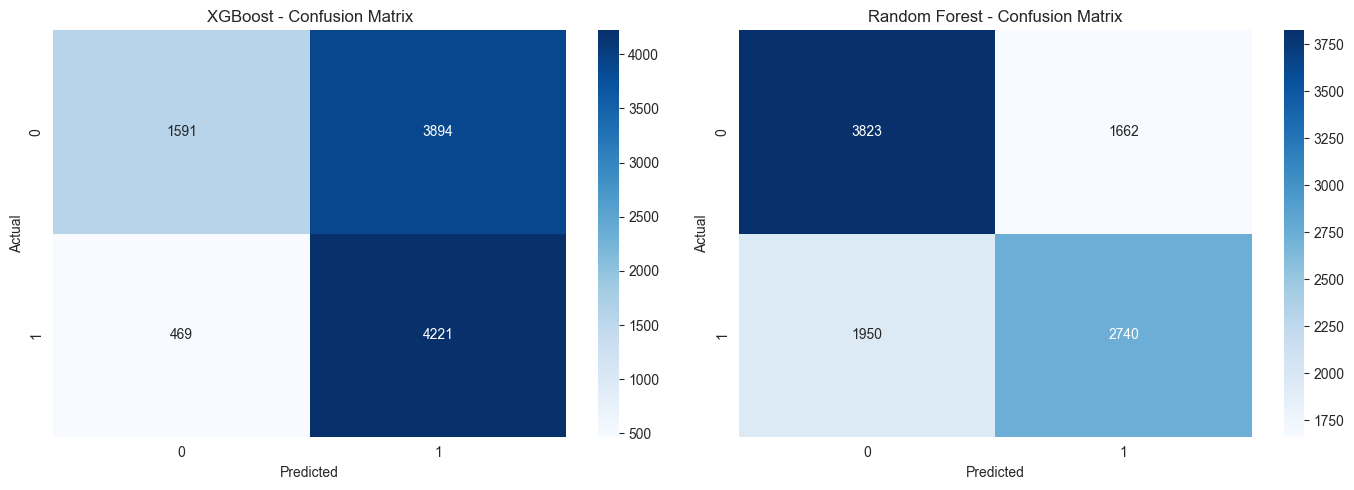

🏃 View run Final_Test_Evaluation at: http://localhost:5000/#/experiments/668770909263748700/runs/9f235fa85c5e449da3536137eb57eb0d
🧪 View experiment at: http://localhost:5000/#/experiments/668770909263748700


In [11]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
xgb_test_pred = best_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, xgb_test_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
rf_test_pred = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Log confusion matrix plot to MLflow
with mlflow.start_run(run_name="Final_Test_Evaluation", nested=True):
    mlflow.log_artifact('confusion_matrices.png')

## 7. Summary

This notebook performed hyperparameter tuning for XGBoost and Random Forest models:

1. **Data**: Used the same feature engineering pipeline and feature selection as baseline
2. **Tuning Method**: RandomizedSearchCV with 30 iterations and 3-fold cross-validation
3. **Optimization Target**: F1 score (balances precision and recall for imbalanced data)
4. **Tracking**: All experiments logged to MLflow (hyperparameter-tuning experiment)

Run `mlflow ui --port 5000` to view all experiments and compare runs.

In [12]:
# Final summary table
print("="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {final_metrics['test_accuracy']:.4f}")
print(f"  F1 Score:  {final_metrics['test_f1']:.4f}")
print(f"  Precision: {final_metrics['test_precision']:.4f}")
print(f"  Recall:    {final_metrics['test_recall']:.4f}")
print(f"  ROC AUC:   {final_metrics['test_roc_auc']:.4f}")
print("\nAll runs tracked in MLflow: http://localhost:5000")

HYPERPARAMETER TUNING SUMMARY

Best Model: XGBoost

Test Set Performance:
  Accuracy:  0.5712
  F1 Score:  0.6593
  Precision: 0.5201
  Recall:    0.9000
  ROC AUC:   0.6975

All runs tracked in MLflow: http://localhost:5000
